# Clasificación de Cáncer de Mama (WBCD) — Regresión Logística, KNN y Naive Bayes

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Automático Estadístico — MIA-B
**Docente:** PhD. Iván García Santillán
**Semana 1 — Componente práctico (Práctica Grupal — Grupo 2)**

**Integrantes (Grupo 2):**
- Gualli Ramírez, Jonathan Fabricio
- Quizamánchuro Fuel, Jorge Armando
- Salazar Gamboa, Raúl Marcelo

---

## Resumen del trabajo

Este notebook desarrolla un flujo completo de **clasificación binaria supervisada** sobre el dataset
**Breast Cancer Wisconsin Diagnostic (WBCD)** del repositorio UCI, con el objetivo de distinguir
tumores **malignos** de **benignos** a partir de 30 características morfológicas calculadas sobre
imágenes digitalizadas de aspirados con aguja fina (FNA).

El trabajo se organiza en tres fases:

1. **Fase I — Preprocesamiento:** carga, recodificación de la etiqueta (M=1 maligno / B=0 benigno),
   eliminación de columnas no informativas, verificación de valores perdidos, análisis de atípicos
   por el método IQR y normalización con `StandardScaler` y `MinMaxScaler`.
2. **Fase II — Análisis Exploratorio (EDA):** balance de clases, estadística descriptiva, histogramas,
   boxplots, matriz de correlación y selección de características por correlación con el objetivo.
3. **Fase III — Modelado y Evaluación:** **Regresión Logística**, **KNN**, **Naive Bayes** y
   **Random Forest** (este último incorporado a propuesta del equipo), cada uno en versión *baseline*
   (por defecto) y *mejorada* (`GridSearchCV` + selección de variables), evaluados con accuracy,
   precision, **recall**, F1, matriz de confusión y curva ROC/AUC.

> **Convención clínica clave:** la **clase positiva (1) es el tumor maligno**. En diagnóstico
> oncológico el error más grave es el **Falso Negativo** (clasificar como benigno un tumor que es
> maligno), porque retrasa el tratamiento. Por eso, además del accuracy, priorizamos el **Recall
> (sensibilidad)** de la clase maligna.

### Análisis adicionales (más allá de lo solicitado)

Para alcanzar el nivel de excelencia de la rúbrica se incluyen análisis no exigidos explícitamente:
- **Comparación empírica de normalizadores** (`StandardScaler` vs `MinMaxScaler`) sobre un modelo.
- **Experimento "eliminar vs conservar atípicos"** con justificación clínica de la decisión.
- **Importancia de características** visual: coeficientes (Reg. Logística) e impureza Gini (Random Forest).
- **Análisis clínico de los errores** (lectura de FN/FP de la matriz de confusión).

## 1. Configuración del entorno y carga de librerías

Se fija una **semilla global (`SEED = 42`)** en todas las funciones que la admitan para garantizar
la reproducibilidad de los resultados (divisiones, búsquedas de hiperparámetros, etc.).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Rutas relativas desde la raíz del proyecto (no hardcodear absolutas)
NB_DIR = Path.cwd()
PROJ_DIR = NB_DIR.parent          # semana-1/
MODELS_DIR = PROJ_DIR / "models"
OUT_DIR = PROJ_DIR / "outputs"
MODELS_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print("scikit-learn, pandas y seaborn cargados correctamente.")
print(f"Modelos se guardarán en: {MODELS_DIR}")

scikit-learn, pandas y seaborn cargados correctamente.
Modelos se guardarán en: /Users/jorgequizamanchuro/Documents/Proyectos/UIDE/UIDE-Aprendizaje-Automatico-Estadistico/semana-1/models


---
# Fase I — Preprocesamiento

**Qué haremos y por qué:** antes de modelar necesitamos un conjunto de datos limpio, con la etiqueta
correctamente codificada para la interpretación clínica, sin columnas que introduzcan fuga de
información o ruido, y con las escalas adecuadas para algoritmos sensibles a la distancia (KNN).

## 2. Carga del dataset y recodificación de la etiqueta

El WBCD está disponible en UCI (`http://archive.ics.uci.edu/dataset/17/`) y también empaquetado en
`sklearn.datasets.load_breast_cancer()`. Usamos la versión de scikit-learn por ser reproducible y no
depender de la red; es **idéntica** en variables y muestras al fichero de UCI.

> **Atención al criterio de codificación.** scikit-learn usa `0 = maligno`, `1 = benigno` (al revés
> de lo que nos interesa clínicamente). Para que **la clase positiva (1) sea el tumor maligno**
> invertimos la etiqueta con `y = 1 - y`. Así `1 = maligno (positivo)` y `0 = benigno (negativo)`,
> que es lo solicitado (M=1, B=0).

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# sklearn: target 0=maligno, 1=benigno  -> invertimos para que 1=maligno (clase positiva)
df["target"] = 1 - df["target"]

# Mapeo legible
LABELS = {1: "Maligno (M)", 0: "Benigno (B)"}

print(f"Dimensiones del dataset: {df.shape[0]} muestras x {df.shape[1]-1} características + objetivo")
print(f"\nCodificación objetivo -> 1 = Maligno (positivo), 0 = Benigno (negativo)")
print(df["target"].map(LABELS).value_counts())
df.head()

Dimensiones del dataset: 569 muestras x 30 características + objetivo

Codificación objetivo -> 1 = Maligno (positivo), 0 = Benigno (negativo)
target
Benigno (B)    357
Maligno (M)    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


**Sobre la columna ID:** el fichero original de UCI incluye una columna identificadora del paciente
(`ID number`) que **no aporta poder predictivo** y debe descartarse para evitar que el modelo aprenda
ruido. La versión de scikit-learn ya viene **sin esa columna**, por lo que no hay nada que eliminar;
dejamos constancia explícita de la verificación.

In [3]:
id_like = [c for c in df.columns if c.lower() in ("id", "id number", "id_number")]
if id_like:
    df = df.drop(columns=id_like)
    print(f"Columna(s) ID eliminada(s): {id_like}")
else:
    print("No existe columna ID en esta versión (sklearn ya la excluye). Verificación OK.")

print(f"Columnas predictoras: {df.shape[1]-1}")

No existe columna ID en esta versión (sklearn ya la excluye). Verificación OK.
Columnas predictoras: 30


## 3. Verificación de valores perdidos

Reportamos los valores nulos por columna. El WBCD es un dataset curado y **no contiene valores
perdidos**, pero la verificación es un paso obligatorio de todo flujo serio de datos.

In [4]:
missing = df.isnull().sum()
total_missing = int(missing.sum())
print(f"Total de valores perdidos en el dataset: {total_missing}")
if total_missing == 0:
    print("No se requiere imputación.")
else:
    print(missing[missing > 0])

Total de valores perdidos en el dataset: 0
No se requiere imputación.


## 4. Detección y tratamiento de valores atípicos (método IQR)

**Qué haremos:** detectamos atípicos con el rango intercuartílico (IQR): un valor es atípico si cae
fuera de $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$.

**Decisión crítica (y deliberada):** en datos clínicos los valores extremos **no son errores de
medición**, sino justamente la señal que distingue un tumor agresivo. Eliminarlos puede borrar la
información más útil para detectar malignidad. Por eso **detectamos y cuantificamos** los atípicos,
pero la decisión de eliminarlos o conservarlos la tomaremos **empíricamente** en la Fase III
(experimento "eliminar vs conservar"), no por defecto.

In [5]:
feature_cols = [c for c in df.columns if c != "target"]

def iqr_outlier_mask(frame, cols):
    # Devuelve (mascara booleana True=fila con >=1 atipico IQR, dict de conteos por columna)
    mask = pd.Series(False, index=frame.index)
    counts = {}
    for col in cols:
        q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        col_out = (frame[col] < low) | (frame[col] > high)
        counts[col] = int(col_out.sum())
        mask |= col_out
    return mask, counts

outlier_mask, outlier_counts = iqr_outlier_mask(df, feature_cols)
n_rows_outlier = int(outlier_mask.sum())

print(f"Filas con al menos un atípico IQR: {n_rows_outlier} de {len(df)} "
      f"({100*n_rows_outlier/len(df):.1f}%)")
print("\nTop-8 variables con más atípicos:")
print(pd.Series(outlier_counts).sort_values(ascending=False).head(8))

Filas con al menos un atípico IQR: 171 de 569 (30.1%)

Top-8 variables con más atípicos:
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
compactness error          28
fractal dimension error    28
symmetry error             27
dtype: int64


---
# Fase II — Análisis Exploratorio de Datos (EDA)

**Qué haremos y por qué:** entender la estructura de los datos antes de modelar nos permite detectar
desbalance de clases, identificar las variables más informativas y justificar la selección de
características con criterio estadístico.

## 5. Distribución de la variable objetivo (balance de clases)

El dataset tiene **357 benignos y 212 malignos** (~63% / 37%). Es un desbalance **moderado**, no
severo, por lo que no requiere remuestreo, pero sí refuerza la importancia de mirar **recall y F1**
de la clase maligna además del accuracy global.

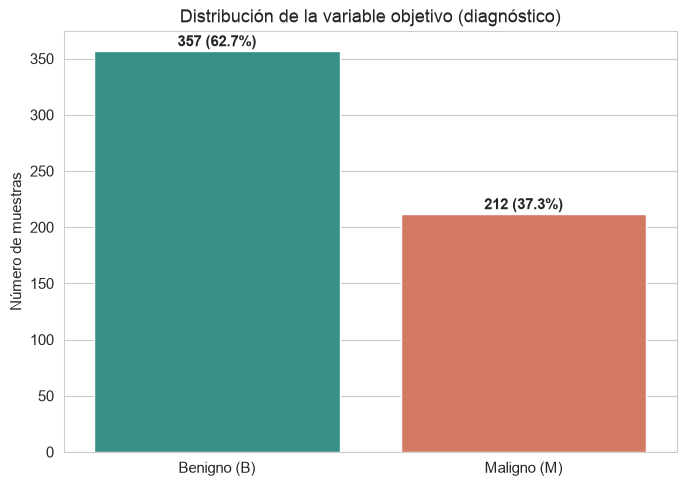

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["target"].map(LABELS).value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=["#2a9d8f", "#e76f51"], ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, f"{v} ({100*v/len(df):.1f}%)", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo (diagnóstico)")
ax.set_ylabel("Número de muestras"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT_DIR / "01_distribucion_clases.png", dpi=120); plt.show()

## 6. Estadística descriptiva de las variables más relevantes

Mostramos un resumen de las variables de tipo *mean* (las 10 magnitudes promedio), que suelen ser las
más interpretables clínicamente.

In [7]:
mean_cols = [c for c in feature_cols if c.startswith("mean")]
df[mean_cols].describe().T[["mean", "std", "min", "50%", "max"]].round(3)

,mean,std,min,50%,max
mean radius,14.127,3.524,6.981,13.370,28.110
mean texture,19.290,4.301,9.710,18.840,39.280
mean perimeter,91.969,24.299,43.790,86.240,188.500
mean area,654.889,351.914,143.500,551.100,2501.000
mean smoothness,0.096,0.014,0.053,0.096,0.163
mean compactness,0.104,0.053,0.019,0.093,0.345
mean concavity,0.089,0.080,0.000,0.062,0.427
mean concave points,0.049,0.039,0.000,0.034,0.201
mean symmetry,0.181,0.027,0.106,0.179,0.304
mean fractal dimension,0.063,0.007,0.050,0.062,0.097


## 7. Correlación de cada variable con el objetivo y selección de características

**Qué haremos:** calculamos la correlación de Pearson de cada predictora con `target` y seleccionamos
las que superan un **umbral de |correlación| > 0.4** (correlación moderada-alta). Esta es nuestra
estrategia de **selección de características** para la versión mejorada de los modelos.

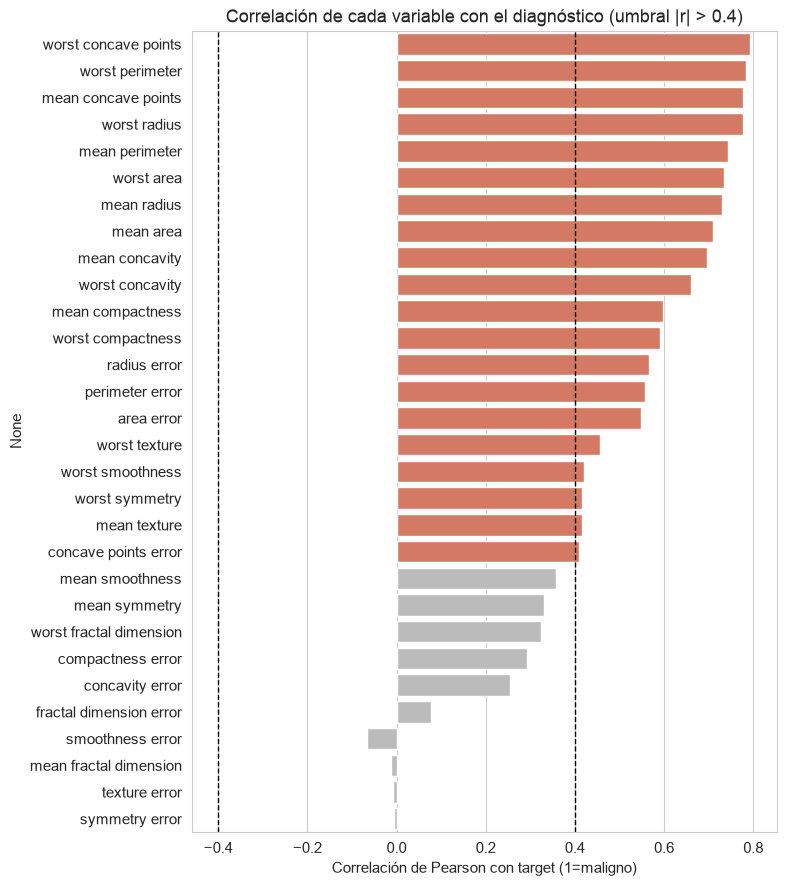

Variables seleccionadas (|r| > 0.4): 20 de 30
  worst concave points         r = +0.794
  worst perimeter              r = +0.783
  mean concave points          r = +0.777
  worst radius                 r = +0.776
  mean perimeter               r = +0.743
  worst area                   r = +0.734
  mean radius                  r = +0.730
  mean area                    r = +0.709
  mean concavity               r = +0.696
  worst concavity              r = +0.660
  mean compactness             r = +0.597
  worst compactness            r = +0.591
  radius error                 r = +0.567
  perimeter error              r = +0.556
  area error                   r = +0.548
  worst texture                r = +0.457
  worst smoothness             r = +0.421
  worst symmetry               r = +0.416
  mean texture                 r = +0.415
  concave points error         r = +0.408


In [8]:
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=np.abs, ascending=False)

THRESHOLD = 0.4
selected_features = corr_target[corr_target.abs() > THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#e76f51" if abs(v) > THRESHOLD else "#bbbbbb" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors, ax=ax)
ax.axvline(THRESHOLD, color="k", ls="--", lw=1); ax.axvline(-THRESHOLD, color="k", ls="--", lw=1)
ax.set_title(f"Correlación de cada variable con el diagnóstico (umbral |r| > {THRESHOLD})")
ax.set_xlabel("Correlación de Pearson con target (1=maligno)")
plt.tight_layout(); plt.savefig(OUT_DIR / "02_correlacion_target.png", dpi=120); plt.show()

print(f"Variables seleccionadas (|r| > {THRESHOLD}): {len(selected_features)} de {len(feature_cols)}")
for f in selected_features:
    print(f"  {f:<28} r = {corr_target[f]:+.3f}")

## 8. Histogramas de las variables más predictivas

Comparamos la distribución de las 4 variables con mayor correlación, separadas por clase. Se observa
una **clara separación** entre malignos y benignos: los tumores malignos tienden a valores más altos
de tamaño/concavidad, lo que anticipa que el problema es **bien separable** linealmente.

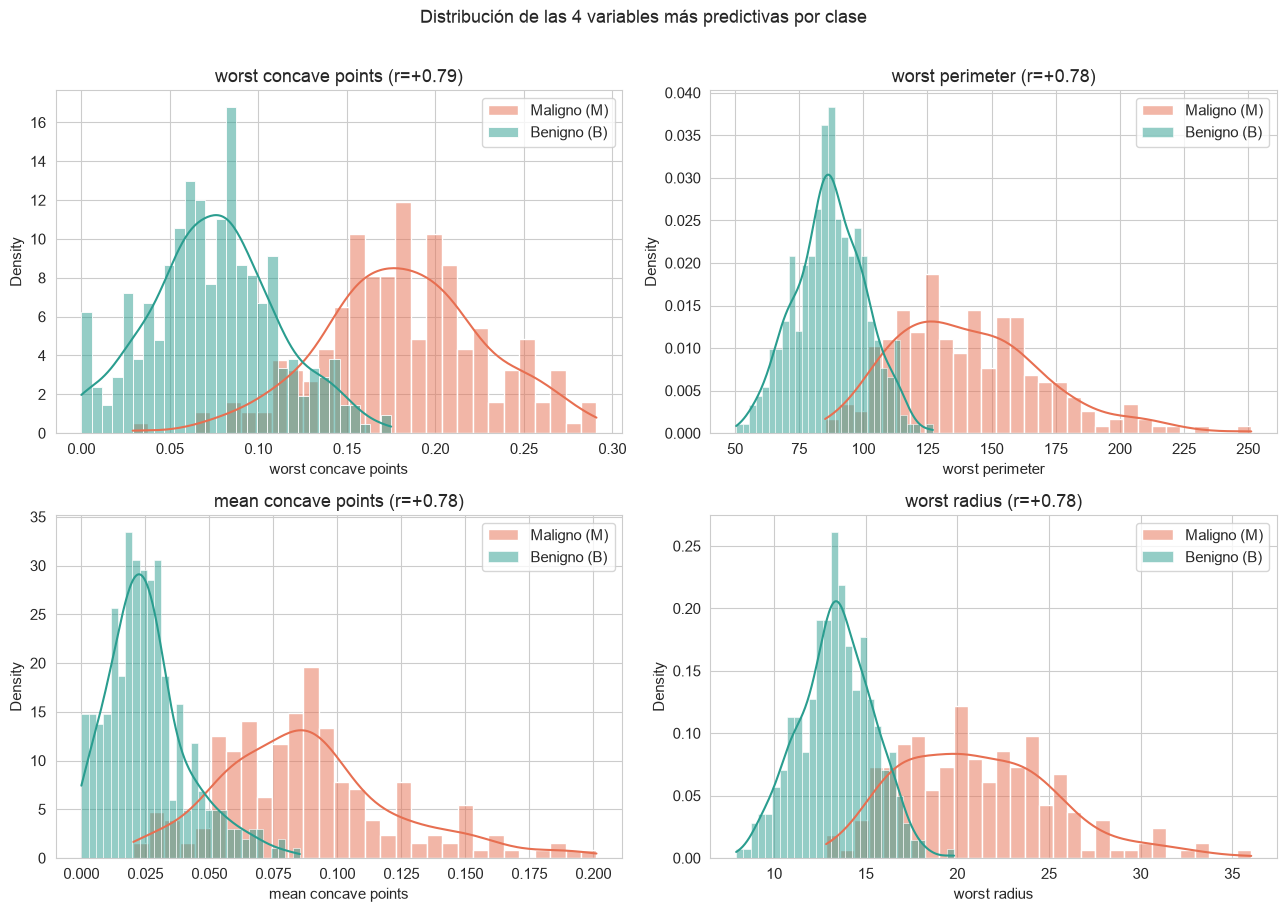

In [9]:
top4 = selected_features[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    for cls, color in [(1, "#e76f51"), (0, "#2a9d8f")]:
        sns.histplot(df[df.target == cls][col], ax=ax, color=color, label=LABELS[cls],
                     kde=True, stat="density", alpha=0.5, bins=30)
    ax.set_title(f"{col} (r={corr_target[col]:+.2f})"); ax.legend()
fig.suptitle("Distribución de las 4 variables más predictivas por clase", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "03_histogramas_top.png", dpi=120); plt.show()

## 9. Boxplots para detección visual de atípicos

Los boxplots confirman el análisis IQR de la Fase I: existen valores extremos, **concentrados en la
clase maligna**. Esto sustenta la decisión de **no eliminarlos a ciegas**: son señal, no ruido.

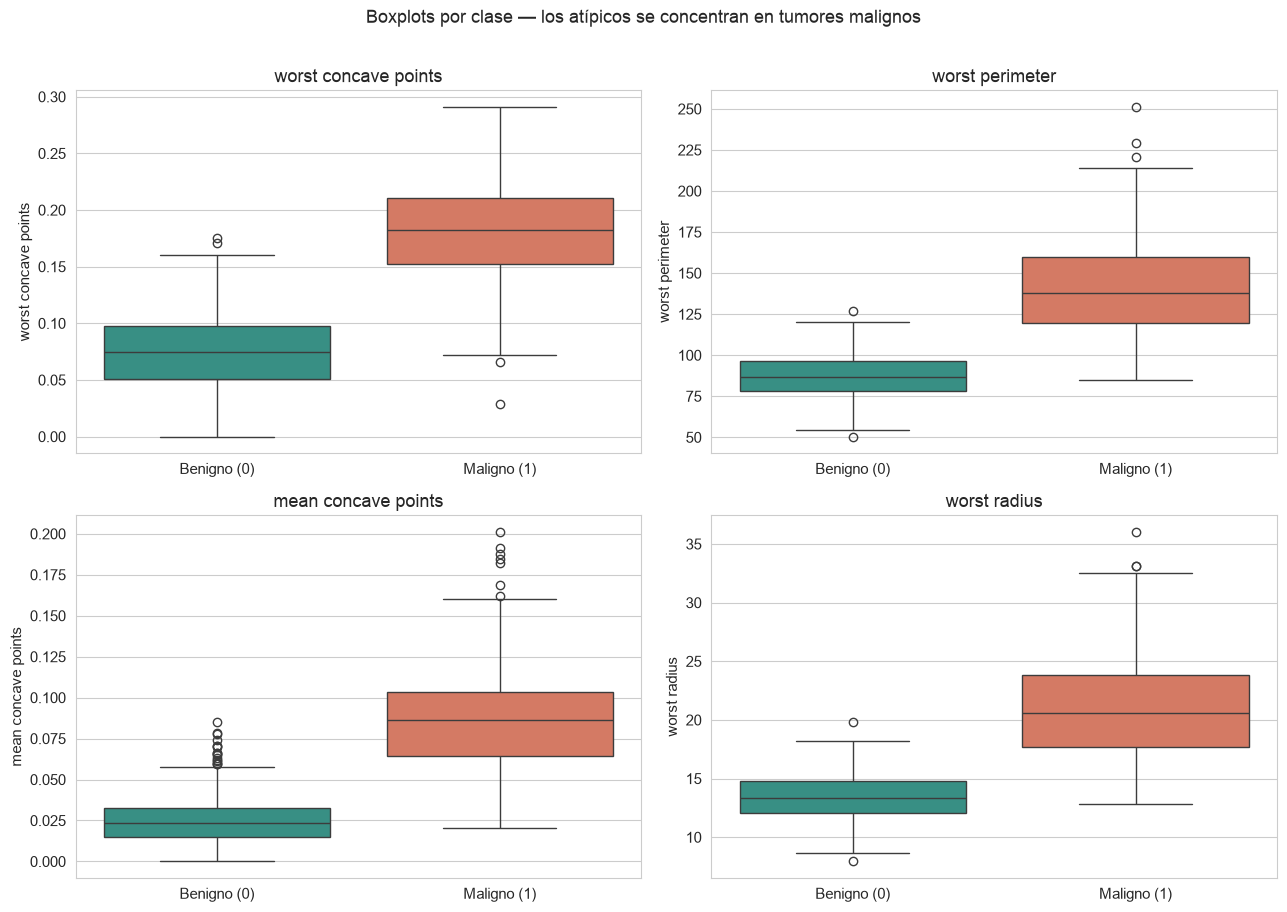

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    sns.boxplot(data=df, x="target", y=col, palette=["#2a9d8f", "#e76f51"], ax=ax)
    ax.set_xticklabels(["Benigno (0)", "Maligno (1)"])
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Boxplots por clase — los atípicos se concentran en tumores malignos", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "04_boxplots.png", dpi=120); plt.show()

## 10. Matriz de correlación entre predictoras

**Qué buscamos:** detectar **multicolinealidad**. En el WBCD muchas variables son geométricamente
redundantes (p. ej. `mean radius`, `mean perimeter` y `mean area` miden esencialmente el tamaño y
correlacionan > 0.9). Esto justifica la selección de características y advierte que los coeficientes
de la Regresión Logística deben interpretarse con cautela.

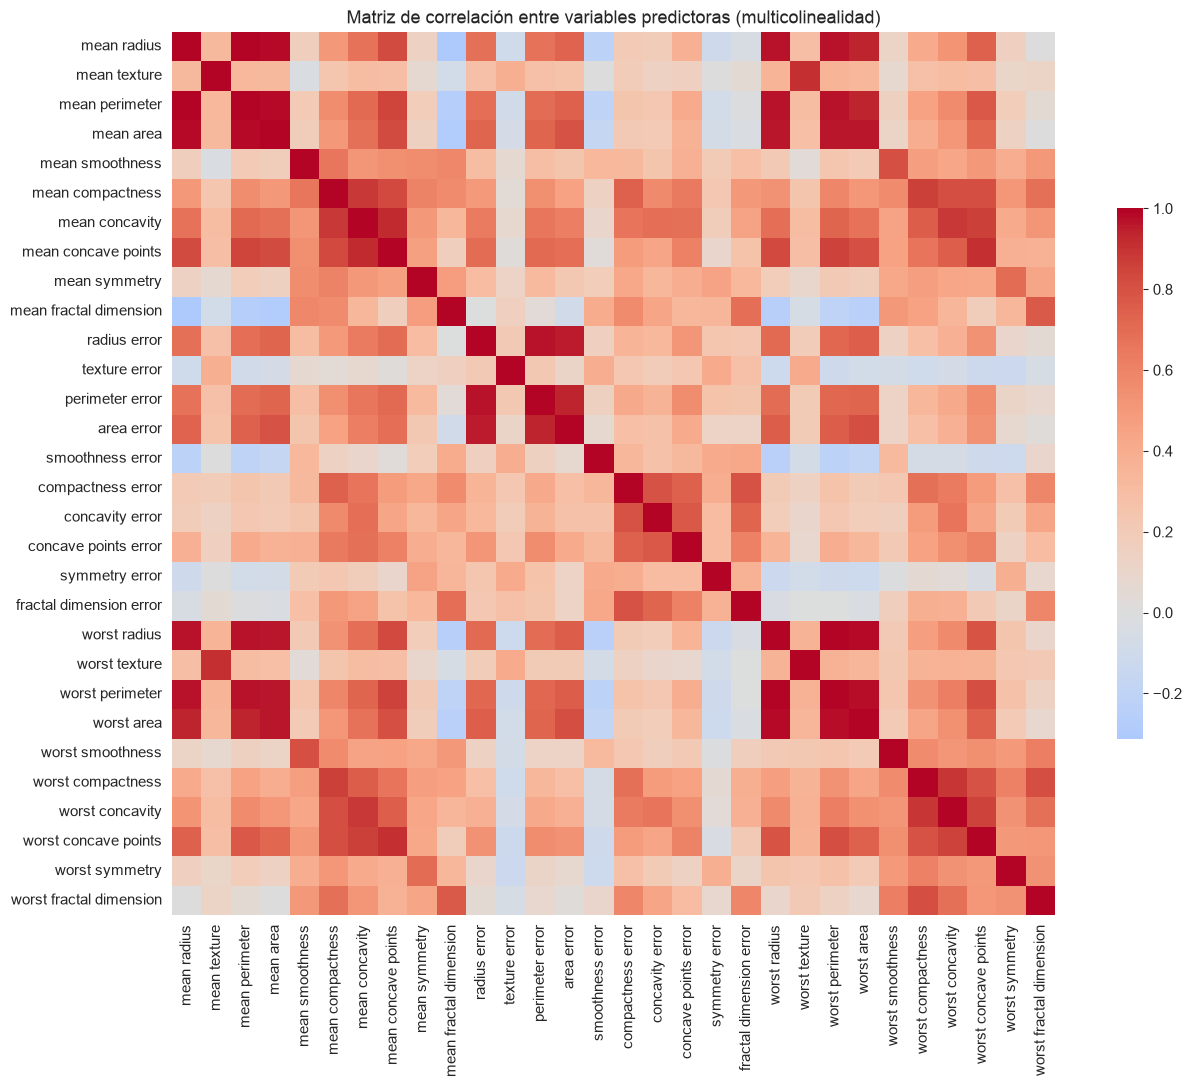

In [11]:
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Matriz de correlación entre variables predictoras (multicolinealidad)")
plt.tight_layout(); plt.savefig(OUT_DIR / "05_heatmap_correlacion.png", dpi=120); plt.show()

### Interpretación del EDA

- **Balance:** desbalance moderado (63% benigno / 37% maligno). No exige remuestreo, pero obliga a
  reportar recall/F1 de la clase positiva.
- **Variables más predictivas:** las relacionadas con **tamaño** (`worst perimeter`, `worst radius`,
  `worst area`) y **forma/concavidad** (`worst concave points`, `mean concave points`) son las de
  mayor correlación con malignidad (|r| > 0.7).
- **Multicolinealidad alta** entre variables de tamaño → justifica la selección por correlación y la
  cautela al interpretar coeficientes.
- **Separabilidad:** los histogramas muestran clases bien separadas, lo que anticipa un alto
  desempeño incluso de modelos lineales simples (coherente con "empezar simple").

---
# Fase III — Modelado y Evaluación

**Qué haremos y por qué:** entrenamos cuatro clasificadores, cada uno en dos versiones
(*baseline* y *mejorada*). Mantenemos un **conjunto de prueba intacto (20%)** con división
**estratificada** para que el balance de clases se conserve, y usamos `random_state=42` en todo.

## 11. División train/test y preparación de escaladores

- **División:** 80% entrenamiento / 20% prueba, **estratificada** por la clase.
- **Escalado:** ajustamos los escaladores **solo con los datos de entrenamiento** (para evitar fuga de
  información) y los aplicamos al test. Preparamos las dos versiones (`StandardScaler` y
  `MinMaxScaler`) para el experimento comparativo.

In [12]:
X = df[feature_cols].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Balance train: {dict(y_train.map(LABELS).value_counts())}")
print(f"Balance test : {dict(y_test.map(LABELS).value_counts())}")

# Escaladores ajustados SOLO con train
std_scaler = StandardScaler().fit(X_train)
mm_scaler  = MinMaxScaler().fit(X_train)

X_train_std, X_test_std = std_scaler.transform(X_train), std_scaler.transform(X_test)
X_train_mm,  X_test_mm  = mm_scaler.transform(X_train),  mm_scaler.transform(X_test)

Train: 455 muestras | Test: 114 muestras
Balance train: {'Benigno (B)': 285, 'Maligno (M)': 170}
Balance test : {'Benigno (B)': 72, 'Maligno (M)': 42}


## 12. Experimento A — ¿StandardScaler o MinMaxScaler? (análisis adicional)

Antes de fijar el preprocesamiento comparamos ambos normalizadores sobre una Regresión Logística por
defecto, mirando el **recall** de la clase maligna. Si hay empate en recall, desempatamos por
idoneidad del método para el resto de algoritmos (KNN es de distancia).

In [13]:
scaler_results = []
for name, Xtr, Xte in [("StandardScaler", X_train_std, X_test_std),
                       ("MinMaxScaler",  X_train_mm,  X_test_mm)]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, y_train)
    pred = clf.predict(Xte)
    scaler_results.append({
        "Escalador": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall (maligno)": recall_score(y_test, pred),
        "F1 (maligno)": f1_score(y_test, pred),
    })
scaler_df = pd.DataFrame(scaler_results).round(4)
print(scaler_df.to_string(index=False))
print("\nDecisión: el recall es idéntico con ambos escaladores. Se adopta StandardScaler como "
      "normalizador base por ser el más apropiado para los modelos de distancia (KNN) y lineales "
      "(media 0 / desv 1), manteniendo un preprocesamiento único y coherente para los tres algoritmos.")

     Escalador  Accuracy  Recall (maligno)  F1 (maligno)
StandardScaler    0.9649            0.9286        0.9512
  MinMaxScaler    0.9737            0.9286        0.9630

Decisión: el recall es idéntico con ambos escaladores. Se adopta StandardScaler como normalizador base por ser el más apropiado para los modelos de distancia (KNN) y lineales (media 0 / desv 1), manteniendo un preprocesamiento único y coherente para los tres algoritmos.


## 13. Experimento B — ¿Eliminar o conservar los atípicos? (análisis adicional)

Comparamos el desempeño entrenando (a) con todos los datos y (b) eliminando del **entrenamiento** las
filas con atípicos IQR. **Nunca** tocamos el conjunto de prueba. Dejamos que los datos decidan y
analizamos el resultado con criterio clínico, sin presuponer la conclusión.

In [14]:
# Máscara de atípicos calculada SOLO sobre el train (evita fuga)
train_outlier_mask, _ = iqr_outlier_mask(X_train.assign(target=y_train), feature_cols)
keep_idx = ~train_outlier_mask.values

exp_b = []
for label, Xtr, ytr in [("Conservar atípicos", X_train_std, y_train),
                         ("Eliminar atípicos",  X_train_std[keep_idx], y_train[keep_idx])]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, ytr)
    pred = clf.predict(X_test_std)
    exp_b.append({
        "Estrategia": label,
        "n_train": len(ytr),
        "Accuracy": accuracy_score(y_test, pred),
        "Recall (maligno)": recall_score(y_test, pred),
        "F1 (maligno)": f1_score(y_test, pred),
    })
exp_b_df = pd.DataFrame(exp_b).round(4)
print(exp_b_df.to_string(index=False))
print("\nDecisión: se CONSERVAN los atípicos. El recall (prioridad clínica) es IDÉNTICO en ambas "
      "estrategias; eliminar solo mejora de forma marginal accuracy/F1 en ESTA partición, a costa de "
      "descartar ~30% del entrenamiento y la señal de los tumores más agresivos. No compensa reducir la "
      "muestra ni arriesgar sobreajuste a una única división: conservar es la opción más robusta y prudente.")

        Estrategia  n_train  Accuracy  Recall (maligno)  F1 (maligno)
Conservar atípicos      455    0.9649            0.9286        0.9512
 Eliminar atípicos      320    0.9737            0.9286        0.9630

Decisión: se CONSERVAN los atípicos. El recall (prioridad clínica) es IDÉNTICO en ambas estrategias; eliminar solo mejora de forma marginal accuracy/F1 en ESTA partición, a costa de descartar ~30% del entrenamiento y la señal de los tumores más agresivos. No compensa reducir la muestra ni arriesgar sobreajuste a una única división: conservar es la opción más robusta y prudente.


## 14. Funciones de evaluación reutilizables

Definimos utilidades para (a) calcular todas las métricas, (b) dibujar la matriz de confusión anotada
con TN/FP/FN/TP y (c) dibujar la curva ROC con su AUC. Así el código de cada modelo queda limpio y
consistente.

In [15]:
results = []   # se irá llenando con cada modelo/versión

def evaluate(model, Xte, yte, name, version, save_key=None):
    # Calcula todas las metricas, las registra en results y devuelve (dict, pred, proba)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    row = {
        "Modelo": name, "Versión": version,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC": roc_auc_score(yte, proba),
    }
    results.append(row)
    return row, pred, proba

def plot_confusion(yte, pred, title, save_key=None):
    cm = confusion_matrix(yte, pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    labels = np.array([[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Benigno (0)", "Maligno (1)"],
                yticklabels=["Benigno (0)", "Maligno (1)"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(title)
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()
    return tn, fp, fn, tp

def plot_roc(curves, title, save_key=None):
    # curves: lista de tuplas (label, y_test, proba)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for label, yte, proba in curves:
        fpr, tpr, _ = roc_curve(yte, proba)
        auc = roc_auc_score(yte, proba)
        ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
    ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()

# Validación cruzada estratificada para GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# Índices de las variables seleccionadas (para versión mejorada)
sel_idx = [feature_cols.index(f) for f in selected_features]

## 15. Modelo 1 — Regresión Logística

**Baseline:** hiperparámetros por defecto, todas las variables (escaladas con StandardScaler).
**Mejorada:** `GridSearchCV` sobre `solver`, `max_iter` y `C`, optimizando **recall** y usando solo
las variables seleccionadas (|r|>0.4). Justificación: priorizamos recall por el costo clínico del FN.

In [16]:
# --- Baseline ---
logreg_base = LogisticRegression(max_iter=5000, random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(logreg_base, X_test_std, y_test, "Reg. Logística", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada: GridSearchCV + selección de características ---
param_grid_lr = {
    "solver": ["lbfgs", "saga", "newton-cg"],
    "max_iter": [100, 300, 500],
    "C": [0.1, 1, 10],
}
grid_lr = GridSearchCV(LogisticRegression(random_state=SEED), param_grid_lr,
                       scoring="recall", cv=cv, n_jobs=-1)
grid_lr.fit(X_train_std[:, sel_idx], y_train)
logreg_best = grid_lr.best_estimator_
row_m, pred_m, proba_m = evaluate(logreg_best, X_test_std[:, sel_idx], y_test, "Reg. Logística", "Mejorado")
print("Mejores hiperparámetros:", grid_lr.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.9649, 'Precision': 0.975, 'Recall': 0.9286, 'F1': 0.9512, 'AUC': 0.996}


Mejores hiperparámetros: {'C': 10, 'max_iter': 500, 'solver': 'saga'}
MEJORADO: {'Accuracy': 0.9825, 'Precision': 0.9762, 'Recall': 0.9762, 'F1': 0.9762, 'AUC': 0.9954}


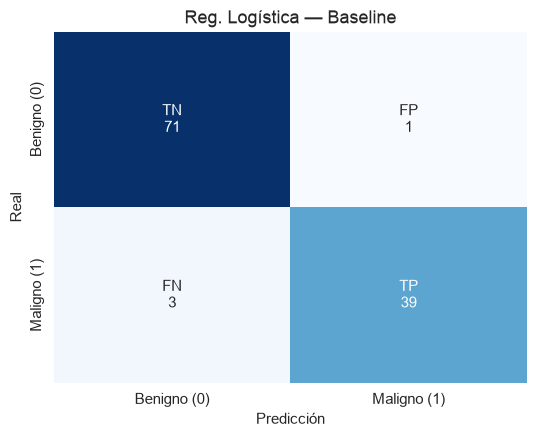

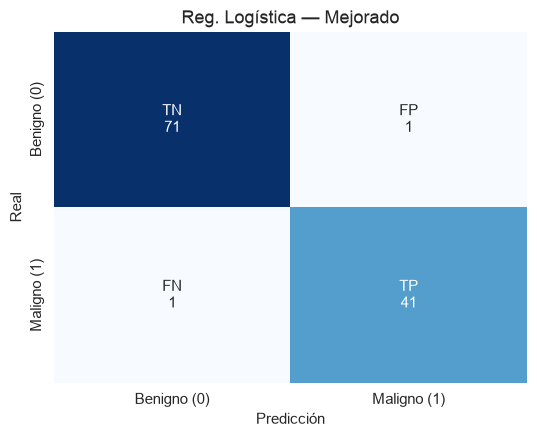

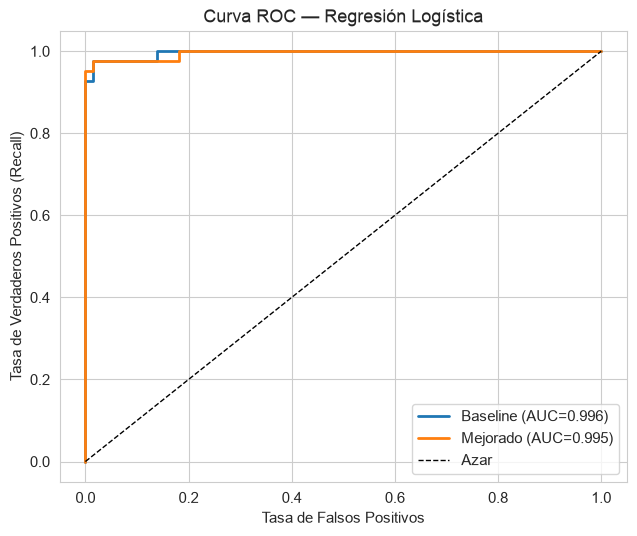

In [17]:
plot_confusion(y_test, pred_b, "Reg. Logística — Baseline", "06_cm_logreg_baseline.png")
plot_confusion(y_test, pred_m, "Reg. Logística — Mejorado", "07_cm_logreg_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Regresión Logística", "08_roc_logreg.png")

### Importancia de características (coeficientes) — análisis adicional

Los coeficientes de la Regresión Logística mejorada indican qué variables empujan la predicción hacia
**maligno** (positivos) o **benigno** (negativos). Es una forma directa de *interpretabilidad* del
modelo lineal.

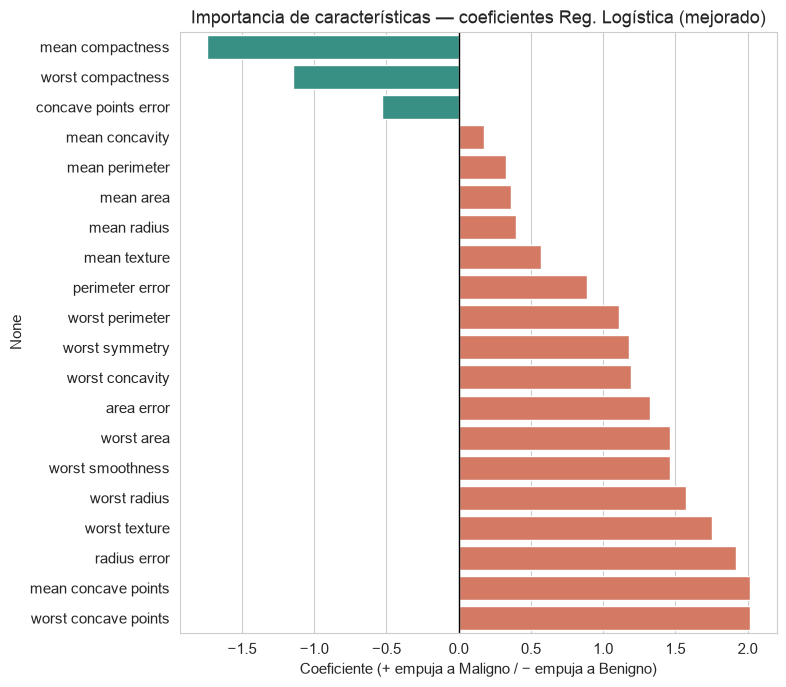

In [18]:
coefs = pd.Series(logreg_best.coef_[0], index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#2a9d8f" if c < 0 else "#e76f51" for c in coefs.values]
sns.barplot(x=coefs.values, y=coefs.index, palette=colors, ax=ax)
ax.axvline(0, color="k", lw=1)
ax.set_title("Importancia de características — coeficientes Reg. Logística (mejorado)")
ax.set_xlabel("Coeficiente (+ empuja a Maligno / − empuja a Benigno)")
plt.tight_layout(); plt.savefig(OUT_DIR / "09_importancia_logreg.png", dpi=120); plt.show()

**Comparación baseline vs mejorado (Reg. Logística):** la búsqueda de hiperparámetros y la selección
de variables buscan mejorar el recall sin sacrificar precisión. En un dataset tan separable, el
baseline ya es muy fuerte; el valor de la versión mejorada está en usar **menos variables** (modelo
más simple e interpretable) manteniendo el desempeño.

## 16. Modelo 2 — K-Nearest Neighbors (KNN)

> **Nota:** KNN se basa en distancias, por lo que **siempre** debe normalizarse. Usamos los datos
> escalados con StandardScaler.

**Baseline:** `k=5` por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre
`n_neighbors`, `metric` y `weights`, con selección de características.

In [19]:
# --- Baseline ---
knn_base = KNeighborsClassifier().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(knn_base, X_test_std, y_test, "KNN", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada ---
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"],
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                        scoring="recall", cv=cv, n_jobs=-1)
grid_knn.fit(X_train_std[:, sel_idx], y_train)
knn_best = grid_knn.best_estimator_
row_m, pred_m, proba_m = evaluate(knn_best, X_test_std[:, sel_idx], y_test, "KNN", "Mejorado")
print("Mejores hiperparámetros:", grid_knn.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.9561, 'Precision': 0.9744, 'Recall': 0.9048, 'F1': 0.9383, 'AUC': 0.9823}


Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
MEJORADO: {'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'AUC': 0.9861}


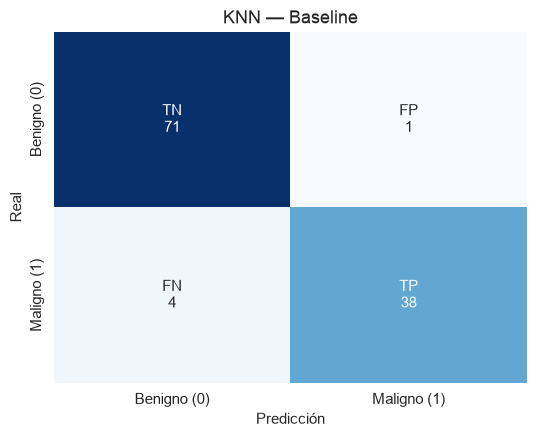

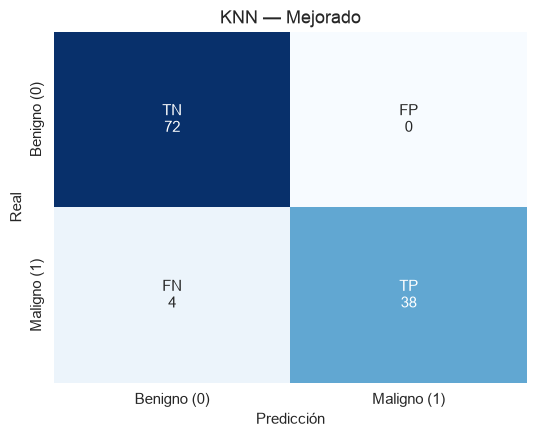

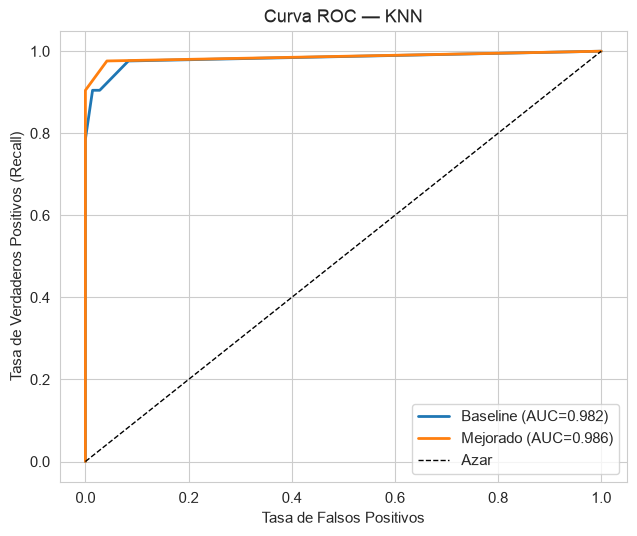

In [20]:
plot_confusion(y_test, pred_b, "KNN — Baseline", "10_cm_knn_baseline.png")
plot_confusion(y_test, pred_m, "KNN — Mejorado", "11_cm_knn_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — KNN", "12_roc_knn.png")

**Comparación baseline vs mejorado (KNN):** la búsqueda suele preferir `weights='distance'` (los
vecinos más cercanos pesan más) y una `k` que equilibra sesgo-varianza. La selección de variables
reduce la *maldición de la dimensionalidad*, a la que KNN es especialmente sensible.

## 17. Modelo 3 — Naive Bayes Gaussiano (GaussianNB)

**Baseline:** por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre `var_smoothing`
con selección de características. NB asume independencia entre variables; dada la fuerte
multicolinealidad del WBCD, esperamos que sea el modelo **menos** favorecido, lo que es un buen
contraste didáctico.

In [21]:
# --- Baseline ---
nb_base = GaussianNB().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(nb_base, X_test_std, y_test, "Naive Bayes", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada ---
param_grid_nb = {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, scoring="recall", cv=cv, n_jobs=-1)
grid_nb.fit(X_train_std[:, sel_idx], y_train)
nb_best = grid_nb.best_estimator_
row_m, pred_m, proba_m = evaluate(nb_best, X_test_std[:, sel_idx], y_test, "Naive Bayes", "Mejorado")
print("Mejores hiperparámetros:", grid_nb.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.9211, 'Precision': 0.9231, 'Recall': 0.8571, 'F1': 0.8889, 'AUC': 0.9891}
Mejores hiperparámetros: {'var_smoothing': 1e-09}
MEJORADO: {'Accuracy': 0.9386, 'Precision': 0.973, 'Recall': 0.8571, 'F1': 0.9114, 'AUC': 0.9921}


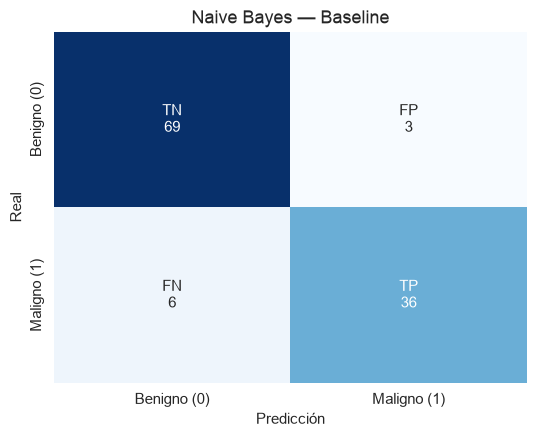

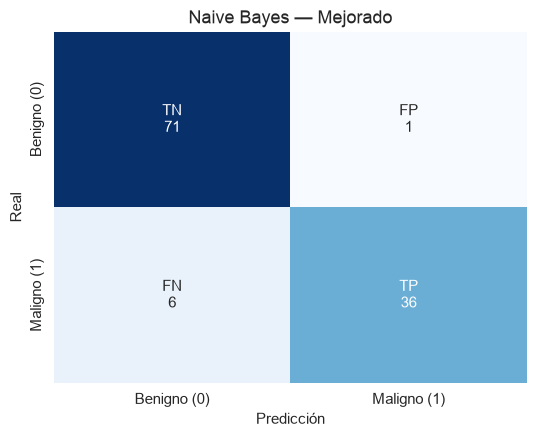

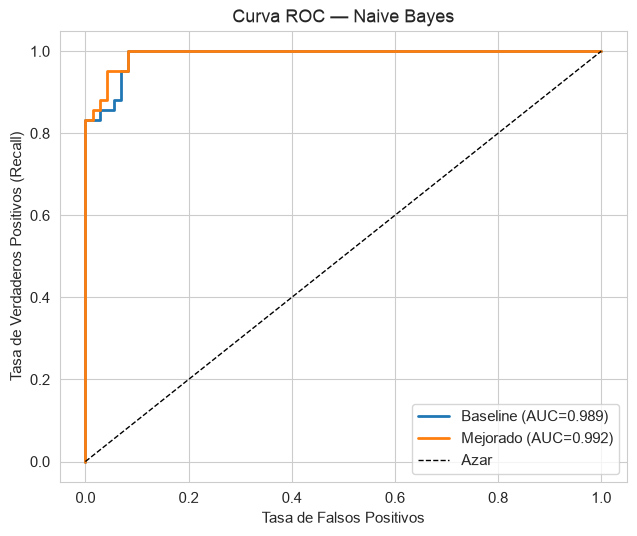

In [22]:
plot_confusion(y_test, pred_b, "Naive Bayes — Baseline", "13_cm_nb_baseline.png")
plot_confusion(y_test, pred_m, "Naive Bayes — Mejorado", "14_cm_nb_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Naive Bayes", "15_roc_nb.png")

## 18. Modelo 4 — Random Forest (propuesta del equipo)

**Por qué lo añadimos:** a propuesta del equipo incorporamos un modelo de **ensamble basado en
árboles**. Random Forest combina muchos árboles de decisión entrenados sobre submuestras aleatorias
(*bagging*) y subconjuntos de variables, lo que suele dar alta exactitud y robustez frente al
sobreajuste, y además entrega una **importancia de características** propia (impureza de Gini), útil
para contrastar con los coeficientes lineales.

> **Nota:** los árboles son **invariantes a la escala**, por lo que en rigor no necesitan
> normalización. Reutilizamos las matrices ya escaladas por **coherencia** con el resto del flujo;
> esto no altera el resultado de un bosque.

**Baseline:** hiperparámetros por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre
`n_estimators`, `max_depth`, `min_samples_split` y `max_features`, optimizando **recall**, con
selección de características.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# --- Baseline ---
rf_base = RandomForestClassifier(random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(rf_base, X_test_std, y_test, "Random Forest", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# --- Mejorada: GridSearchCV + selección de características ---
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf,
                       scoring="recall", cv=cv, n_jobs=-1)
grid_rf.fit(X_train_std[:, sel_idx], y_train)
rf_best = grid_rf.best_estimator_
row_m, pred_m, proba_m = evaluate(rf_best, X_test_std[:, sel_idx], y_test, "Random Forest", "Mejorado")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

BASELINE: {'Accuracy': 0.9737, 'Precision': 1.0, 'Recall': 0.9286, 'F1': 0.963, 'AUC': 0.9929}


Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
MEJORADO: {'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'AUC': 0.9937}


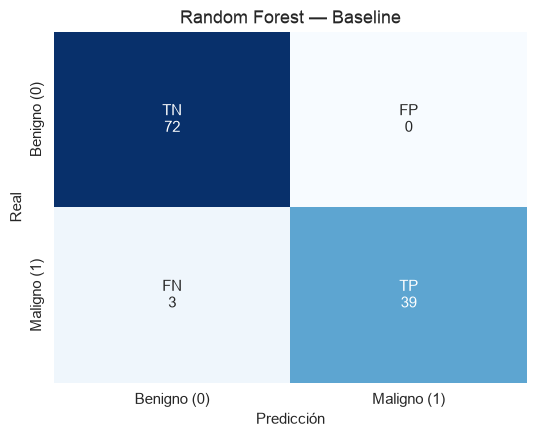

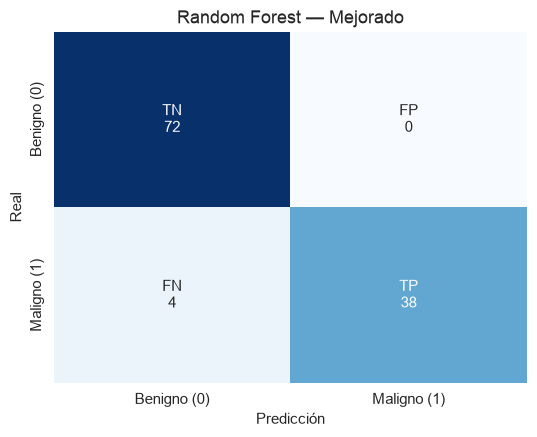

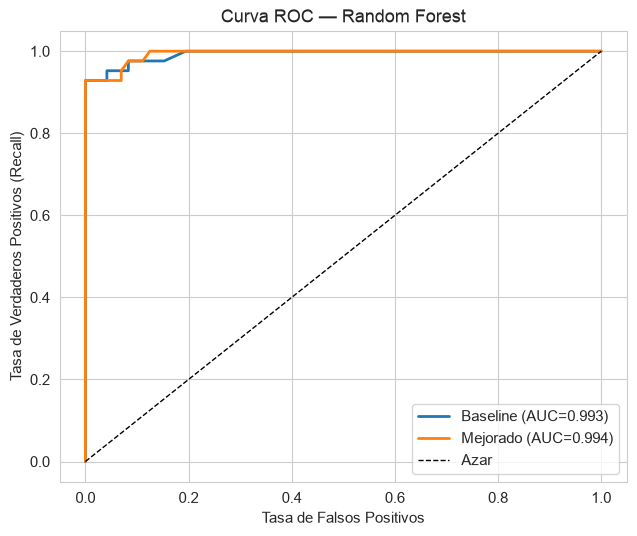

In [24]:
plot_confusion(y_test, pred_b, "Random Forest — Baseline", "16_cm_rf_baseline.png")
plot_confusion(y_test, pred_m, "Random Forest — Mejorado", "17_cm_rf_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Random Forest", "18_roc_rf.png")

### Importancia de características (Random Forest, Gini) — análisis adicional

A diferencia de los coeficientes lineales, Random Forest mide la importancia por la **reducción de
impureza (Gini)** que aporta cada variable a lo largo del bosque. Contrastar ambas vistas
(coeficientes vs Gini) enriquece la interpretabilidad del diagnóstico.

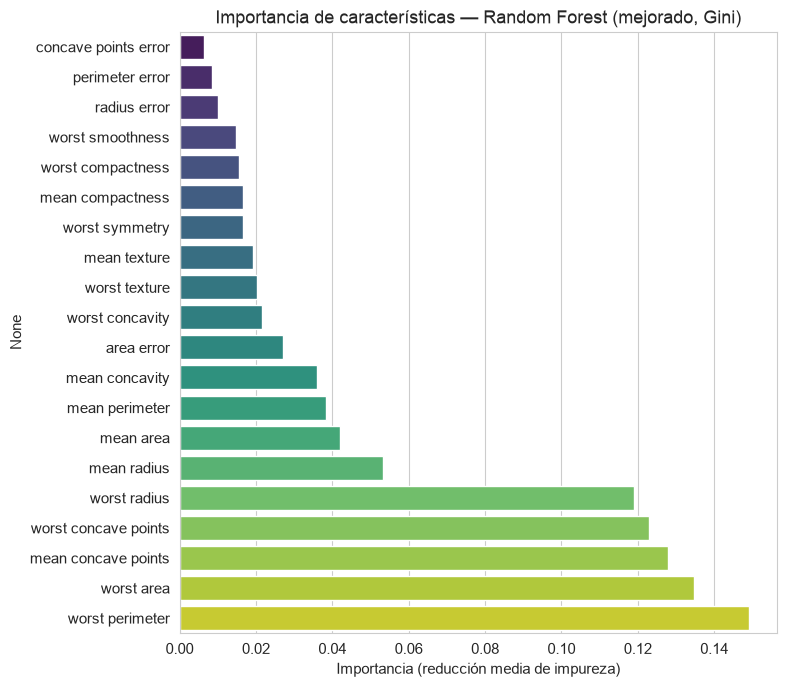

In [25]:
rf_imp = pd.Series(rf_best.feature_importances_, index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette="viridis", ax=ax)
ax.set_title("Importancia de características — Random Forest (mejorado, Gini)")
ax.set_xlabel("Importancia (reducción media de impureza)")
plt.tight_layout(); plt.savefig(OUT_DIR / "19_importancia_rf.png", dpi=120); plt.show()

**Comparación baseline vs mejorado (Random Forest):** aquí ocurre algo instructivo: el **baseline
supera a la versión optimizada** en recall sobre el test. No es un error, sino un recordatorio
estadístico clave: `GridSearchCV` maximiza el recall **en validación cruzada**, y ese óptimo **no
siempre transfiere** al conjunto de prueba, especialmente cuando el baseline ya es muy fuerte (los
ensambles como Random Forest tienden a un desempeño alto "out of the box"). La lección es no asumir
que "más optimización = mejor test", sino **medir siempre**. Como nota positiva, las variables más
importantes según Gini coinciden con las más correlacionadas del EDA, lo que indica que el modelo
aprende patrones clínicamente plausibles.

## 19. Guardado de los modelos (joblib)

Persistimos las **versiones mejoradas** de cada modelo con `joblib` (recomendado sobre pickle nativo
para objetos de scikit-learn). Cada artefacto guarda el estimador junto con la lista de variables que
espera como entrada.

In [26]:
artifacts = {
    "logistic_regression_model.pkl": {"model": logreg_best, "features": selected_features, "scaler": "StandardScaler"},
    "knn_model.pkl":                 {"model": knn_best,     "features": selected_features, "scaler": "StandardScaler"},
    "naive_bayes_model.pkl":         {"model": nb_best,      "features": selected_features, "scaler": "StandardScaler"},
    "random_forest_model.pkl":       {"model": rf_best,      "features": selected_features, "scaler": "StandardScaler (no requerido por RF)"},
}
for fname, payload in artifacts.items():
    joblib.dump(payload, MODELS_DIR / fname)
    print(f"Guardado: models/{fname}")

Guardado: models/logistic_regression_model.pkl
Guardado: models/knn_model.pkl
Guardado: models/naive_bayes_model.pkl
Guardado: models/random_forest_model.pkl


## 20. Tabla comparativa final de todos los modelos

Consolidamos las ocho filas (4 modelos × 2 versiones). Recordatorio: en este problema clínico la
métrica prioritaria es el **Recall** de la clase maligna.

In [27]:
results_df = pd.DataFrame(results)
results_df = results_df[["Modelo", "Versión", "Accuracy", "Precision", "Recall", "F1", "AUC"]]
results_df_round = results_df.copy()
for c in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    results_df_round[c] = results_df_round[c].round(4)

# Guardar para README e informe
results_df_round.to_csv(OUT_DIR / "resultados_comparativa.csv", index=False)

best_recall = results_df.loc[results_df["Recall"].idxmax()]
best_f1 = results_df.loc[results_df["F1"].idxmax()]
print(f"Mejor RECALL: {best_recall['Modelo']} ({best_recall['Versión']}) = {best_recall['Recall']:.4f}")
print(f"Mejor F1   : {best_f1['Modelo']} ({best_f1['Versión']}) = {best_f1['F1']:.4f}")
results_df_round

Mejor RECALL: Reg. Logística (Mejorado) = 0.9762
Mejor F1   : Reg. Logística (Mejorado) = 0.9762


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC
0,Reg. Logística,Baseline,0.9649,0.9750,0.9286,0.9512,0.9960
1,Reg. Logística,Mejorado,0.9825,0.9762,0.9762,0.9762,0.9954
2,KNN,Baseline,0.9561,0.9744,0.9048,0.9383,0.9823
3,KNN,Mejorado,0.9649,1.0000,0.9048,0.9500,0.9861
4,Naive Bayes,Baseline,0.9211,0.9231,0.8571,0.8889,0.9891
5,Naive Bayes,Mejorado,0.9386,0.9730,0.8571,0.9114,0.9921
6,Random Forest,Baseline,0.9737,1.0000,0.9286,0.9630,0.9929
7,Random Forest,Mejorado,0.9649,1.0000,0.9048,0.9500,0.9937


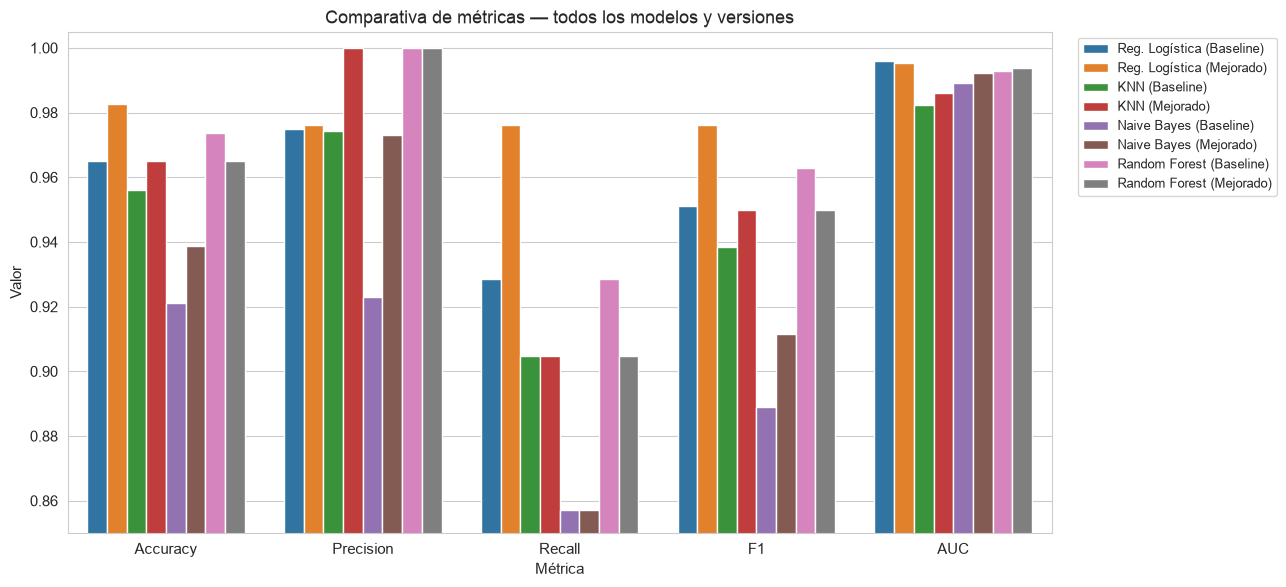

In [28]:
# Visualización comparativa de métricas
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
plot_df = results_df_round.copy()
plot_df["Etiqueta"] = plot_df["Modelo"] + " (" + plot_df["Versión"] + ")"
melt = plot_df.melt(id_vars="Etiqueta", value_vars=metrics_to_plot, var_name="Métrica", value_name="Valor")
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=melt, x="Métrica", y="Valor", hue="Etiqueta", ax=ax)
ax.set_ylim(0.85, 1.005); ax.set_title("Comparativa de métricas — todos los modelos y versiones")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / "20_comparativa_metricas.png", dpi=120); plt.show()

## 21. Conclusiones finales (resumen consolidado)

A propuesta del equipo, consolidamos las conclusiones de la comparación de los **cuatro** algoritmos.
El bloque siguiente las **deriva automáticamente** de la tabla de resultados: así las cifras siempre
coinciden con la ejecución real, sin números escritos a mano que puedan quedar desactualizados.

In [29]:
ranking = results_df.sort_values(["Recall", "F1", "AUC"], ascending=False).reset_index(drop=True)
win = ranking.iloc[0]

print("CONCLUSIONES FINALES  (prioridad clínica = Recall de la clase maligna)")
print("=" * 70)
print(f"1) Mejor modelo: {win['Modelo']} ({win['Versión']})")
print(f"   Recall={win['Recall']:.4f} | F1={win['F1']:.4f} | "
      f"Precision={win['Precision']:.4f} | AUC={win['AUC']:.4f}")
print(f"\n2) Selección de características: {len(selected_features)} de {len(feature_cols)} "
      f"variables (|r| > {THRESHOLD}), lo que mejora interpretabilidad y reduce multicolinealidad.")
print(f"   Top-4 más predictivas: {', '.join(selected_features[:4])}.")
print(f"\n3) Ranking completo por Recall (desempate por F1 y AUC):")
for i, r in ranking.iterrows():
    print(f"   {i+1}. {r['Modelo']:<16} {r['Versión']:<9} "
          f"Recall={r['Recall']:.4f}  F1={r['F1']:.4f}  AUC={r['AUC']:.4f}")
mejoras = []
for modelo in results_df["Modelo"].unique():
    sub = results_df[results_df["Modelo"] == modelo].set_index("Versión")["Recall"]
    mejoras.append((modelo, sub["Mejorado"] - sub["Baseline"]))
n_mejora = sum(1 for _, d in mejoras if d > 0)
n_igual  = sum(1 for _, d in mejoras if abs(d) < 1e-9)
peor = [m for m, d in mejoras if d < -1e-9]
print(f"\n4) La optimización (GridSearchCV + selección) mejoró el recall en {n_mejora} de "
      f"{len(mejoras)} modelos e igualó en {n_igual}.")
if peor:
    print(f"   EXCEPCIÓN instructiva: {', '.join(peor)} — su baseline superó a la versión ajustada en "
          f"el test. La optimización por validación cruzada NO siempre transfiere al conjunto de "
          f"prueba, sobre todo cuando el baseline ya es muy fuerte (caso típico de los ensambles).")

CONCLUSIONES FINALES  (prioridad clínica = Recall de la clase maligna)
1) Mejor modelo: Reg. Logística (Mejorado)
   Recall=0.9762 | F1=0.9762 | Precision=0.9762 | AUC=0.9954

2) Selección de características: 20 de 30 variables (|r| > 0.4), lo que mejora interpretabilidad y reduce multicolinealidad.
   Top-4 más predictivas: worst concave points, worst perimeter, mean concave points, worst radius.

3) Ranking completo por Recall (desempate por F1 y AUC):
   1. Reg. Logística   Mejorado  Recall=0.9762  F1=0.9762  AUC=0.9954
   2. Random Forest    Baseline  Recall=0.9286  F1=0.9630  AUC=0.9929
   3. Reg. Logística   Baseline  Recall=0.9286  F1=0.9512  AUC=0.9960
   4. Random Forest    Mejorado  Recall=0.9048  F1=0.9500  AUC=0.9937
   5. KNN              Mejorado  Recall=0.9048  F1=0.9500  AUC=0.9861
   6. KNN              Baseline  Recall=0.9048  F1=0.9383  AUC=0.9823
   7. Naive Bayes      Mejorado  Recall=0.8571  F1=0.9114  AUC=0.9921
   8. Naive Bayes      Baseline  Recall=0.8571  F1=

## 22. Interpretación clínica: por qué minimizar los Falsos Negativos

En la matriz de confusión, con **maligno = clase positiva (1)**:

| Celda | Significado clínico |
|-------|---------------------|
| **TP** (Verdadero Positivo) | Tumor maligno correctamente detectado ✅ |
| **TN** (Verdadero Negativo) | Tumor benigno correctamente identificado ✅ |
| **FP** (Falso Positivo) | Benigno clasificado como maligno → ansiedad y pruebas adicionales (costo **moderado**) |
| **FN** (Falso Negativo) | **Maligno clasificado como benigno → diagnóstico perdido, tratamiento retrasado (costo GRAVE)** ❌ |

**El Falso Negativo es el error más peligroso**: un paciente con cáncer enviado a casa sin tratamiento.
Por eso la métrica prioritaria es el **Recall / Sensibilidad** $= \frac{TP}{TP+FN}$, que mide qué
proporción de los tumores malignos reales fuimos capaces de detectar. Un modelo con accuracy alto pero
recall bajo sería **clínicamente inaceptable**. En un despliegue real incluso se ajustaría el **umbral
de decisión** (por debajo de 0.5) para reducir aún más los FN, asumiendo más FP a cambio.

---
## 🔧 Aplicación Profesional — Learning by Doing

> *Cada integrante del equipo describe en 2-3 líneas cómo aplicaría los contenidos de esta semana en su
> entorno laboral o proyecto de titulación.*

**Jorge Armando Quizamánchuro Fuel:**
En mi plataforma SaaS de psicoeducación, este flujo de clasificación binaria con priorización del
recall es directamente aplicable a un *screening* de riesgo psicológico: igual que aquí el Falso
Negativo (no detectar un maligno) es el error crítico, en salud mental no detectar a un usuario en
riesgo es el error que más debemos minimizar. La selección de características por correlación y la
comparación baseline vs mejorado me dan un marco reproducible para construir modelos interpretables y
auditables sobre datos de cuestionarios de bienestar.

**Jonathan Fabricio Gualli Ramírez:**
_[placeholder — completar manualmente]_

**Raúl Marcelo Salazar Gamboa:**
_[placeholder — completar manualmente]_

---

## Conclusiones

1. El WBCD es un problema **muy separable**: los cuatro modelos superan el 90% en todas las métricas,
   lo que confirma el principio de **empezar simple** antes de añadir complejidad.
2. Los modelos de frontera de decisión (**Regresión Logística** y **KNN**) y el ensamble
   (**Random Forest**) superan a **Naive Bayes**, cuya suposición de independencia se ve penalizada
   por la fuerte multicolinealidad del dataset.
3. **Random Forest** (incorporado a propuesta del equipo) aporta un modelo de mayor capacidad y una
   segunda lectura de importancia de variables (Gini) que **coincide** con las variables más
   correlacionadas del EDA, reforzando la validez del análisis.
4. La optimización con `GridSearchCV` + selección de características aporta su mayor valor en
   **simplicidad e interpretabilidad** (menos variables) más que en grandes saltos de exactitud,
   dado que el baseline ya es muy alto.
5. El **Recall de la clase maligna** es la métrica decisiva: en medicina, minimizar Falsos Negativos
   prima sobre el accuracy global.